# Articulated Body Dynamics
Reinforcement learning steps environments to collect rollout data. For simulation-based RL, the core is of course about implementing `step()` and running it as fast as possible. Grasping the underlying computation is also critical for identifying physical alignment to reality, analyzing the sensitivity of environment evolution, and knowing the limit/challenging problem instances to simulate. Most of the contents in this module can be found in textbook such as [@featherstone2007] and [@modernrobotics] as standard robot dynamics modelling and computation. In this specific context, dynamics mean the physics law involving force, acceleration and mass/inertia, which are beyond geometry and its differentials in kinematics. For those who are familiar with the Newton's 2nd law, the acceleration of a 1-D particle $a$ is associated to the exerted force $f$ through its mass $m$, as simple as:
$$
f = \frac{d(mv)}{dt} = m\dot{v} = ma
$$

Things are slightly more complicated for dynamics of a strand of rigid body links connected through articulated joints. Rigid bodies are collections of particles so the force and inertial effects must be accounted together. For this the Newton-Euler equation describes the relation in a form similar to the particle case:

$$
\begin{split}
\begin{bmatrix}
\mathbf{\tau}    \\
\mathbf{f}
\end{bmatrix} & = \begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}
\begin{bmatrix}
\dot{\mathbf{\omega}}    \\
\dot{\mathbf{v}}
\end{bmatrix} + \begin{bmatrix}
\mathbf{\omega} \times (\mathcal{I}\mathbf{\omega}) \\
m\mathbf{\omega} \times \mathbf{v}
\end{bmatrix}   \\
& = \begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}\begin{bmatrix}
\dot{\mathbf{\omega}}    \\
\dot{\mathbf{v}}
\end{bmatrix} - \begin{bmatrix}
\mathbf{\omega}\times  &   \mathbf{0}  \\
\mathbf{v}\times &   \mathbf{\omega}\times
\end{bmatrix}^{\top}
\begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}
\begin{bmatrix}
\mathbf{\omega}   \\
\mathbf{v}
\end{bmatrix}
\end{split}
$$
with the skew-asymmetricity of $\mathbf{v}\times$ and $\mathbf{v}\times\mathbf{v}=0$. Here $m$ is the mass of the rigid body and $\mathcal{I}$ is the [inertia tensor](https://en.wikipedia.org/wiki/Moment_of_inertia) about the center-of-mass. $\mathcal{I}$ captures the distribution of material mass of a rigid body and plays the role of particle mass for the rotational motion component. For many basic geometry shapes with a uniform density, the quantity is readily [available](https://en.wikipedia.org/wiki/List_of_moments_of_inertia) from a closed-form integration. [](#eq-newtoneuler) has a resemblance of [](#eq-newton2ndlaw) for also having a linear relation between the mass and acceleration terms. The only structure difference is the extra bias term which is independent of acceleration. This is a fundamental structure for dynamics of rigid and articulated bodies.

:::{note}
The velocity and its differentiation terms here are __spatial velocity and acceleration__ (see the section below). By having the center-of-mass as reference, the acceleration describes the rigid body status as a whole instead of the specific point of the center-of-mass. See section 2.11 in[@featherstone2007] for more detailed discussion about this. 
:::

Rigid bodies in an articulated chain are linked through joints. Applying [](#eq-newtoneuler) to each link in isolation must account for forces due to joints constraining the body motion. In most robotics contexts, the most interested are the resultant motion through the joints due to motors attached to them. The concrete values of contraint forces are usually not part of the desired results. There is thus another way of representing the configuration status of the articulated body and its dynamics with the joint configuration $\mathbf{q}$, called __generalized coordinate__. The dynamic for the generalized coordinate representation is:

$$
\mathbf{\tau} = \mathbf{M}(\mathbf{q})\ddot{\mathbf{q}} + \mathbf{C}(\dot{\mathbf{q}}, \mathbf{q}) 
$$

where $\mathbf{\tau}$ is redefined as toruqes applied to the joints, and $\mathbf{M}$ and $\mathbf{C}$ are playing the similar role as the inertia matrix and bias terms. 

A dynamic model as [](#eq-newtoneuler) or [](#eq-robodyn) can be used for following tasks:
* Causal order: given the current state and applied force/torque from a control policy, solve the joint/link acceleration and hence the future state through time-integration. This is called __forward dynamics__ and basically the underlying simulation task of `step()`. 
* Inverse problem: given the current state and the desired joint/link acceleration (and hence the future state), solve the force/torque needed to let the equation hold. This is called __inverse dynamics__ and can play an important role in control.

In what follows, both forward and inverse dynamcis will be covered while a few building blocks are needed before delving into the concrete algorithms. 









Learning objectives
* Explain the concept of generalized coordinate and velocity in representing the state of articulated bodies;

    Generalized coordinates vector identifies a minimal set q that can determine the full configuration of each link. Generalized velocity is a time derivative q' that identifies the joint angular velocities. We can obtain these velocities for both joints and links. 


* Explain the structure of articulated dynamics equation and identify dependencies of each term on generalized coordinate and velocity;

    tau = M(q)q'' + C(q',q)q' + g(q) 
    tau = joint torques
    M(q) = mass matrix 
    q = generalized coordinates, q' = generalized velocities, q'' = generalized acceleration 
    C(q',q)q' = coriolis and centrifugal effect
    g(q) = gravity bias 


* Explain what are forward and inverse dynamics problems and how are they related to simulation and control in the context of robotics;

    Inverse dynamics: given q, q', q'', find tau using RNEA 
        Related to control (to find exact actual torques needed)
    Forward dynamics: given q, q', tau, find q'' using ABA, or with RNEA + mass matrix assembly 
        Related to simulation (to find the solution of the differential equations that the dynamics of the articulated body to predict its future motion)
    FD is the inverse of ID


* Describe how recursive algorithms work in computing inverse and forward dynamics;

    RNEA has two passes: forward and backward pass
    In forward pass, we propagate kinematics (velocity, acceleration) from root to tip
    In backward pass, we accumulate the forces and extract torques 

    ABA has three passes: forward, backward, forward pass
    In first forward pass, we compute velocities and bias effects
    In backward and second forward pass, we recurse to compute join accelerations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import List, NamedTuple, Optional

# ── Provided spatial-algebra imports ──────────────────────────────────────────
from spatial_algebra import Transform, Motion, Force, Inertia
from math_utils import quat_rot_axis, rotate

nplib = np

In [ ]:
# setup
class JointDofs(NamedTuple):
    motion: Motion


class Link(NamedTuple):
    name:        str
    inertia:     Inertia
    joint_frame: Transform
    com_frame:   Transform
    joint_dofs:  JointDofs


class System(NamedTuple):
    links: List[Link]

    def num_links(self) -> int:
        return len(self.links)

We can import transformation operations from the provided spatial_algebra.py file. 

### Section 1

In [ ]:
# build model based on xml file
def build_threelinks() -> System:
    sx, sy, sz = 0.025, 0.15, 0.025
    rho = 2700.0
    V   = (2*sx) * (2*sy) * (2*sz)
    m   = rho * V  

    Ixx = m * (sy**2 + sz**2) / 3.0
    Iyy = m * (sx**2 + sz**2) / 3.0
    Izz = m * (sx**2 + sy**2) / 3.0
    it  = np.diag([Ixx, Iyy, Izz])
    link_inertia = Inertia.from_it_and_mass(it=it, mass=m)

    z_screw    = Motion(ang=np.array([0., 0., 1.]), lin=np.zeros(3))
    joint_dofs = JointDofs(motion=z_screw)

    identity_rot = np.array([1., 0., 0., 0.]) 

    links = []
    for i in range(3):
        jf_trans = np.array([0., 0., 0.]) if i == 0 else np.array([0., 0.15, 0.])
        joint_frame = Transform(trans=jf_trans, rot=identity_rot)

        com_frame = Transform(trans=np.array([0., 0.15, 0.]), rot=identity_rot)

        links.append(Link(
            name        = f"link_{i}",
            inertia     = link_inertia,
            joint_frame = joint_frame,
            com_frame   = com_frame,
            joint_dofs  = joint_dofs,
        ))

    return System(links=links)

In [ ]:
sys = build_threelinks()

```
<body name="link_0" pos="0 0.15 0" euler="0 0 0">
        <joint name="joint_0" type="hinge" axis="0 0 1" pos="0 -0.15 0"/>
        <geom name="box_link_0" type="box" size=".025 .15 .025" rgba="0.8 0.8 0.8 1" density="2700"/>
</body>
```

1) What are the dimensions of the link?

The shape of each link is defined as a three-dimensional box using 
```
<geom type="box" size=".025 .15 .025"/>
```
In MuJoCo, the size parameter represents half-lengths along each axis, hence the full dimensions are 0.05m × 0.30m × 0.05m.

2) How are the links connected to each other?

The three links are connected by nesting each <body> element inside its parent <body> element. Each child link is placed at pos="0 0.3 0" (relative to its parent’s coordinate
frame), which positions it at the tip of the parent link (since each link is 30cm tall).

Each connection point is a hinge joint defined at pos="0 -0.15
0", meaning the pivot sits at the bottom of each link. The first
joint, joint_0, is anchored to the world origin since link_0
is centered at 0.15m above the origin and the joint is 0.15m
below that center — placing it exactly at (0, 0, 0).

3) What is the furthest distance the 'arm tip' can reach?

Since joint_0 is anchored at the world origin, the arm tip can reach a maximum distance of 0.90m from the base when all three links are fully extended in the same direction.

### Section 2, forward kinetics and velocities

In [ ]:
def forward_kinematics(sys: System, q: np.ndarray):
    T_world_com  = []
    T_parent_com = []

    T_prev = Transform(trans=np.zeros(3), rot=np.array([1., 0., 0., 0.]))

    for i, link in enumerate(sys.links):
        T_world_joint = T_prev.apply_transform(link.joint_frame)

        q_rot = Transform(
            trans = np.zeros(3),
            rot   = quat_rot_axis(np.array([0., 0., 1.]), q[i])
        )

        T_world_com_i = (T_world_joint
                         .apply_transform(q_rot)
                         .apply_transform(link.com_frame))

        T_local = T_world_com_i.create_local(T_prev)

        T_world_com.append(T_world_com_i)
        T_parent_com.append(T_local)
        T_prev = T_world_com_i

    return T_world_com, T_parent_com

Code implementation to compute the world-frame pose of each link's COM (center of mass) given a set of joint angles q. For each link in the chain, the pose of its COM relative to the world frame is obtained from the three transforms:

```        
T_world_joint = T_prev.apply_transform(link.joint_frame)
```
Moves from current link's COM frame to the next joint's pivot frame. 

```
q_rot = Transform(
    trans = np.zeros(3),
    rot   = quat_rot_axis(np.array([0., 0., 1.]), q[i])
)
```
Applies joint rotation q[i] around the z-axis; is configuration dependent. Taken directly from math_utils 

```
T_world_com_i = (T_world_joint
    .apply_transform(q_rot)
    .apply_transform(link.com_frame))
```
Move from rotated joint's pivot frame to the next link's COM. 

Note that three transforms are needed given the robot's physical structure defined in the XML - joint_frame, which tells us where this link's joint is relative to the parent COM, and com_frame, which tells us where this link's COM is relative to its own joint.

A direct result of this algorithm gives us exactly where each link's COM sits in the world and its orientation; we indirectly also obtain the relative transforms between parent and child, which are later used in RNEA and ABA to compute the specific velocities and forces between adjacent link frames, giving the two algorithms a linear runtime. 

In [ ]:
# Note: not used anywhere else in the notebook. Included here for completeness and to show how the T_parent_com transforms are used.
def forward_velocity(sys: System, q: np.ndarray, qd: np.ndarray, T_parent_com: list) -> List[Motion]:
    v_lst  = []
    v_prev = Motion(ang=np.zeros(3), lin=np.zeros(3))  

    for i, link in enumerate(sys.links):
        S_i = link.joint_dofs.motion.apply_inv_transform(link.com_frame)

        # Plücker-transform parent velocity into this link's frame
        v_parent = v_prev.apply_transform(T_parent_com[i])

        v_i = v_parent + S_i * qd[i]

        v_lst.append(v_i)
        v_prev = v_i

    return v_lst

In [ ]:
# Calculate the forward kinematics and velocities for an example configuration
q_demo = np.array([np.pi/6, np.pi/4, -np.pi/3])
qd_demo = np.array([0.5, -0.3, 0.2])

T_world_com, T_parent_com = forward_kinematics(sys, q_demo)
v_lst = forward_velocity(sys, q_demo, qd_demo, T_parent_com)

print("Transform matrices between adjacent links (T_parent_com)")
for i, T in enumerate(T_parent_com):
    print(f"\nT_{i-1}_to_{i} (parent COM -> link {i} COM):")
    print(f"translation: {T.trans}")
    print(f"rotation (quat): {T.rot}")

print("\nSpatial velocities at each link COM")
for i, v in enumerate(v_lst):
    print(f"\nLink {i} spatial velocity:")
    print(f"angular: {v.ang}")
    print(f"linear:  {v.lin}")

Transform matrices between adjacent links (T_parent_com)

T_-1_to_0 (parent COM -> link 0 COM):
translation: [-0.075     0.129904  0.      ]
rotation (quat): [0.965926 0.       0.       0.258819]

T_0_to_1 (parent COM -> link 1 COM):
translation: [-0.106066  0.256066  0.      ]
rotation (quat): [0.92388  0.       0.       0.382683]

T_1_to_2 (parent COM -> link 2 COM):
translation: [0.129904 0.225    0.      ]
rotation (quat): [ 0.866025  0.        0.       -0.5     ]

Spatial velocities at each link COM

Link 0 spatial velocity:
angular: [0.  0.  0.5]
linear:  [0.075 0.    0.   ]

Link 1 spatial velocity:
angular: [0.  0.  0.2]
linear:  [-0.12  0.    0.  ]

Link 2 spatial velocity:
angular: [0.  0.  0.4]
linear:  [-0.075    -0.129904  0.      ]


Using inverse dynamics via RNEA + matrix assembly

In [ ]:
# Recursive Newton-Euler Algorithm (RNEA) ----
# Computes inverse dynamics: joint torques tau = RNEA(q, dq, ddq) to obtain an exact motion
# Also computes gravity and coriolis torques when qd and qdd are zero, respectively.

def inverse_dynamics_rnea(sys: System, q: np.ndarray, qd: np.ndarray, qdd: np.ndarray) -> np.ndarray:
    N = sys.num_links()
    T_world_com, T_parent_com = forward_kinematics(sys, q)

    # Let v and a be the spatial velocity and acceleration of the link COM

    # The velocity of any body can be defined recursively as the sum of 
    # velocity of its paraent and the velocity across the joint connecting 
    # it to its parent
    v_lst = []
    a_lst = []

    # forward pass, in which we walk from base to tip to compute v_i and a_i
    # as well as the coriolis term zeta_i
    gravity_world = np.array([0., -9.81, 0.])
    a_prev = Motion(ang=np.zeros(3), lin=-gravity_world)  
    v_prev = Motion(ang=np.zeros(3), lin=np.zeros(3))

    for i, link in enumerate(sys.links):
        S_i      = link.joint_dofs.motion.apply_inv_transform(link.com_frame)
        v_parent = v_prev.apply_transform(T_parent_com[i])
        a_parent = a_prev.apply_transform(T_parent_com[i])

        v_i    = v_parent + S_i * qd[i]
        zeta_i = v_i.cross_motion(S_i * qd[i])       
        a_i    = a_parent + S_i * qdd[i] + zeta_i

        v_lst.append(v_i)
        a_lst.append(a_i)
        v_prev = v_i
        a_prev = a_i

    # backward pass, in which we calculate the forces at each link COM 
    # and then walk from tip to base to compute the joint torques
    # from the forces acting on the bodies
    f_lst = []

    # first part, we apply Newton-Euler at each link
    for i in range(N):
        Iv     = sys.links[i].inertia.mul(v_lst[i])
        bias   = v_lst[i].cross_force(Iv)
        f_i    = sys.links[i].inertia.mul(a_lst[i]) + bias
        f_lst.append(f_i)

    # second part, we walk backward from tip to base 
    # extracting each link's joint torque by projecting the body force onto the joint axis
    tau = np.zeros(N)
    for i in range(N - 1, -1, -1):
        S_i    = sys.links[i].joint_dofs.motion.apply_inv_transform(sys.links[i].com_frame)
        tau[i] = S_i.dot_force(f_lst[i])
        if i > 0:
            f_in_parent = f_lst[i].apply_inv_transform(T_parent_com[i])
            f_lst[i-1]  = f_lst[i-1] + f_in_parent

    return tau

# Quick test: static pose, zero velocity, zero acceleration
# At q=[pi/4, 0, 0], gravity should require a nonzero torque at joint 0
q_test = np.array([np.pi/4, 0.0, 0.0])
tau_test = inverse_dynamics_rnea(sys, q_test, np.zeros(3), np.zeros(3))
print(f"Gravity torques at q=[pi/4, 0, 0]: {tau_test}")

Gravity torques at q=[pi/4, 0, 0]: [-6.321084  0.        2.107028]


See inline comments regarding details of each pass in RNEA

### Section 3 ABA implementation

If we wanted to reassmble the mass matrix to compute the forward dynamics, we'd call RNEA n+1 times (n=# joints, +1=bias) and assembly M column by column. This become expontential with many degrees of freedom. Thus, we can instead obtain q'' without ever assembling M. 

In [ ]:
def forward_dynamics_aba(sys: System, q: np.ndarray, qd: np.ndarray, tau: np.ndarray) -> np.ndarray:
    N = sys.num_links()
    T_world_com, T_parent_com = forward_kinematics(sys, q)

    # first loop - calculate link poses and velocities
    # similar to RNEA forward pass, but we only need the velocities 
    
    v_lst = forward_velocity(sys, q, qd, T_parent_com)

    # articulated body inertia I_a and bias p_a at each link COM
    I_a_lst = [
        Inertia(inertia_tensor=sys.links[i].inertia.inertia_tensor.copy())
        for i in range(N)
    ]

    p_a_lst = [
        v_lst[i].cross_force(I_a_lst[i].mul(v_lst[i]))
        for i in range(N)
    ]

    # screw axes in the link COM frames 
    S_ss_lst = [
        sys.links[i].joint_dofs.motion.apply_inv_transform(sys.links[i].com_frame)
        for i in range(N)
    ]

    # coriolis term zeta_i = v_i x (S_i * qd_i)
    zeta_lst = [
        v_lst[i].cross_motion(S_ss_lst[i] * qd[i])
        for i in range(N)
    ]
    

    # second loop - backward to complete articulated body inertia and bias
    # proceeds from tip to base, at each link we compute the "reduced" articulated body inertia
    # by projecting out the joint DOF and then propagating the inertia and bias to the
    D_lst = [None] * N
    U_lst = [None] * N
    u_lst = [None] * N

    for i in range(N - 1, -1, -1):
        S_i   = S_ss_lst[i]
        IA_i  = I_a_lst[i]
        pA_i  = p_a_lst[i]

        # U_i = I_a_i * S_i
        # articulated-body inertia projected on the joint axis
        # how much force/torque do we get if we accelerate along the joint axis?
        U_lst[i] = IA_i.mul(S_i)

        # D_i = S_i^T * I_a_i * S_i
        # scalar articulated-body inertia along the joint axis
        D_lst[i] = S_i.dot_force(U_lst[i])

        # u_i = tau_i - S_i^T * pA_i
        # generalized force along the joint axis, after subtracting out the bias force
        u_lst[i] = tau[i] - S_i.dot_force(pA_i)

        # propagate inertia and bias to parent
        if i > 0:
            U_arr         = U_lst[i].to_6darray()
            IA_reduced    = Inertia(
                inertia_tensor = IA_i.inertia_tensor - np.outer(U_arr, U_arr) / D_lst[i]
            )
            IA_in_parent  = IA_reduced.apply_transform(T_parent_com[i])
            I_a_lst[i-1]  = I_a_lst[i-1] + IA_in_parent

            pa_extended   = pA_i + IA_i.mul(zeta_lst[i])
            u_over_D      = u_lst[i] / D_lst[i]
            pa_extended   = pa_extended + Force.from_6darray(U_arr * u_over_D)
            pa_in_parent  = pa_extended.apply_inv_transform(T_parent_com[i])
            p_a_lst[i-1]  = p_a_lst[i-1] + pa_in_parent

    # third loop - calculate joint acceleration 
    gravity_world = np.array([0., -9.81, 0.])
    a_base        = Motion(ang=np.zeros(3), lin=-gravity_world)

    a_lst = [None] * N
    qdd   = []

    for i in range(N):
        a_prev_in_link = (a_base if i == 0 else a_lst[i-1]).apply_transform(T_parent_com[i])

        a_prime = a_prev_in_link + zeta_lst[i]

        qdd_i = (u_lst[i] - U_lst[i].to_6darray() @ a_prime.to_6darray()) / D_lst[i]

        a_lst[i] = a_prime + S_ss_lst[i] * qdd_i

        qdd.append(np.atleast_1d(float(qdd_i)))

    return np.concatenate(qdd)

In [ ]:
def forward_dynamics_aba2(sys: System, q: np.ndarray, qd: np.ndarray, tau: np.ndarray) -> np.ndarray:
    N = sys.num_links()
    T_world_com, T_parent_com = forward_kinematics(sys, q)

    # first loop - calculate link poses and velocities
    v_lst = forward_velocity(sys, q, qd, T_parent_com)

    # articulated body inertia I_a and bias p_a at each link COM
    I_a_lst = [
        Inertia(inertia_tensor=sys.links[i].inertia.inertia_tensor.copy())
        for i in range(N)
    ]

    p_a_lst = [
        v_lst[i].cross_force(Force.from_6darray(I_a_lst[i].inertia_tensor @ v_lst[i].to_6darray()))
        for i in range(N)
    ]

    # screw axes in the link COM frames
    S_ss_lst = [
        sys.links[i].joint_dofs.motion.apply_inv_transform(sys.links[i].com_frame)
        for i in range(N)
    ]

    zeta_lst = [
        v_lst[i].cross_motion(S_ss_lst[i] * qd[i])
        for i in range(N)
    ]

    # second loop - backward pass: articulated body inertia and bias propagation
    D_lst = [None] * N
    U_lst = [None] * N
    u_lst = [None] * N

    for i in range(N - 1, -1, -1):
        S_i  = S_ss_lst[i]
        IA_i = I_a_lst[i]
        pA_i = p_a_lst[i]

        # U_i = I_a_i * S_i  (6x6 matrix times 6-vector -> 6-vector force)
        S_arr    = S_i.to_6darray()
        U_arr    = IA_i.inertia_tensor @ S_arr
        U_lst[i] = U_arr  # store as plain numpy array

        # D_i = S_i^T U_i  (scalar articulated inertia along joint axis)
        D_lst[i] = float(S_arr @ U_arr)

        # u_i = tau_i - S_i^T pA_i
        u_lst[i] = tau[i] - float(S_arr @ pA_i.to_6darray())

        if i > 0:
            # reduced articulated inertia: remove DOF absorbed by joint i
            IA_reduced = Inertia(
                inertia_tensor=IA_i.inertia_tensor - np.outer(U_arr, U_arr) / D_lst[i]
            )
            # propagate reduced inertia to parent frame
            IA_in_parent = IA_reduced.apply_transform(T_parent_com[i])
            I_a_lst[i-1] = I_a_lst[i-1] + IA_in_parent

            # propagate bias to parent: extend with zeta contribution and u/D correction
            pa_extended  = Force.from_6darray(
                pA_i.to_6darray()
                + IA_i.inertia_tensor @ zeta_lst[i].to_6darray()
                + U_arr * (u_lst[i] / D_lst[i])
            )
            pa_in_parent = pa_extended.apply_inv_transform(T_parent_com[i])
            p_a_lst[i-1] = p_a_lst[i-1] + pa_in_parent

    # third loop - forward pass: solve joint accelerations
    gravity_world = np.array([0., -9.81, 0.])
    a_base        = Motion(ang=np.zeros(3), lin=-gravity_world)

    a_lst = [None] * N
    qdd   = []

    for i in range(N):
        a_prev_in_link = (a_base if i == 0 else a_lst[i-1]).apply_transform(T_parent_com[i])
        a_prime        = a_prev_in_link + zeta_lst[i]

        qdd_i   = (u_lst[i] - float(U_lst[i] @ a_prime.to_6darray())) / D_lst[i]
        a_lst[i] = a_prime + S_ss_lst[i] * qdd_i

        qdd.append(np.atleast_1d(float(qdd_i)))

    return np.concatenate(qdd)


### Simulation + visualization

In [ ]:
def simulate(sys: System, q0: np.ndarray, qd0: np.ndarray, tau_fn, dt: float = 0.002, T_final: float = 3.0) -> dict:
    steps = int(T_final / dt)
    N     = sys.num_links()

    t_hist    = np.zeros(steps)
    q_hist    = np.zeros((steps, N))
    qd_hist   = np.zeros((steps, N))
    qdd_hist  = np.zeros((steps, N))
    KE_hist   = np.zeros(steps)
    tip_hist  = np.zeros((steps, 3))
    vn_hist   = np.zeros((steps, N))   

    q, qd = q0.copy(), qd0.copy()

    for k in range(steps):
        tau = tau_fn(q, qd)
        qdd = forward_dynamics_aba(sys, q, qd, tau)

        T_wc, T_pc = forward_kinematics(sys, q)
        v_lst       = forward_velocity(sys, q, qd, T_pc)

        KE = sum(0.5 * v_lst[i].dot_force(sys.links[i].inertia.mul(v_lst[i]))
                 for i in range(N))

        T_tip = T_wc[-1].apply_transform(
            Transform(trans=np.array([0., 0.15, 0.]),
                      rot=np.array([1., 0., 0., 0.]))
        )

        t_hist[k]   = k * dt
        q_hist[k]   = q
        qd_hist[k]  = qd
        qdd_hist[k] = qdd
        KE_hist[k]  = KE
        tip_hist[k] = T_tip.trans
        vn_hist[k]  = [np.linalg.norm(v_lst[i].to_6darray()) for i in range(N)]

        qd = qd + qdd * dt
        q  = q  + qd  * dt

    return dict(t=t_hist, q=q_hist, qd=qd_hist, qdd=qdd_hist,
                KE=KE_hist, tip_pos=tip_hist, link_vel_norms=vn_hist)

In [244]:
def plot_results(results: dict, sys: System):
    t   = results["t"]
    q   = results["q"]
    qd  = results["qd"]
    qdd = results["qdd"]
    KE  = results["KE"]
    tip = results["tip_pos"]

    colours = ["#E63946", "#457B9D", "#2A9D8F"]
    labels  = [f"link_{i}" for i in range(sys.num_links())]

    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("Three-Link Articulated Body Dynamics — Simulation Results")
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # joint positions 
    ax1 = fig.add_subplot(gs[0, 0])
    for i in range(sys.num_links()):
        ax1.plot(t, np.degrees(q[:, i]), color=colours[i], label=labels[i])
    ax1.set_title("(a) Joint Angles (positions)")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Angle [deg]")
    ax1.grid(True, alpha=0.3)

    # joint velocities 
    ax2 = fig.add_subplot(gs[0, 1])
    for i in range(sys.num_links()):
        ax2.plot(t, np.degrees(qd[:, i]), color=colours[i], label=labels[i])
    ax2.set_title("(b) Joint Velocities")
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel("Angular velocity [deg/s]")
    ax2.grid(True, alpha=0.3)

    # joint accelerations 
    ax3 = fig.add_subplot(gs[0, 2])
    for i in range(sys.num_links()):
        ax3.plot(t, np.degrees(qdd[:, i]), color=colours[i], label=labels[i])
    ax3.set_title("(c) Joint Accelerations")
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel("Ang. acceleration [deg/s²]")
    ax3.grid(True, alpha=0.3)

    # kinetic energy 
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(t, KE, color="#6A0572", linewidth=1.5)
    ax4.set_title("(d) Total Kinetic Energy")
    ax4.set_xlabel("Time [s]")
    ax4.set_ylabel("KE [J]")
    ax4.grid(True, alpha=0.3)

    # end-effector trajectory 
    ax5 = fig.add_subplot(gs[1, 1])
    sc = ax5.scatter(tip[:, 0], tip[:, 1], c=t, cmap="plasma",
                     s=2, linewidths=0)
    fig.colorbar(sc, ax=ax5, label="Time [s]")
    ax5.set_title("(e) End-Effector Trajectory (XY)")
    ax5.set_xlabel("X [m]")
    ax5.set_ylabel("Y [m]")
    ax5.set_aspect("equal")
    ax5.grid(True, alpha=0.3)

    # end-effector speed 
    ax6 = fig.add_subplot(gs[1, 2])
    tip_speed = np.linalg.norm(np.gradient(tip, results["t"][1]-results["t"][0], axis=0), axis=1)
    ax6.plot(t, tip_speed, color="#264653", linewidth=1.5)
    ax6.set_title("(h) End-Effector Speed")
    ax6.set_xlabel("Time [s]")
    ax6.set_ylabel("Speed [m/s]")
    ax6.grid(True, alpha=0.3)

    plt.show()


### Verification w mujoco

In [ ]:
import mujoco

def compare_with_mujoco(xml_path: str, sys: System, q: np.ndarray, qd: np.ndarray, tau: np.ndarray):
    mjc_model = mujoco.MjModel.from_xml_path(xml_path)
    mjc_data  = mujoco.MjData(mjc_model)

    mjc_data.qpos[:] = q
    mjc_data.qvel[:] = qd
    mjc_data.qfrc_applied[:] = tau
    mujoco.mj_forward(mjc_model, mjc_data)

    qdd_mujoco = mjc_data.qacc.copy()
    qdd_aba = forward_dynamics_aba(sys, q, qd, tau)

    print("\n=== MuJoCo vs ABA comparison ===")
    print(f"MuJoCo qacc : {qdd_mujoco}")
    print(f"ABA qacc : {qdd_aba}")
    print(f"Max |error| : {np.max(np.abs(qdd_mujoco - qdd_aba)):.2e}")
    return qdd_mujoco, qdd_aba

Joint accelerations at rest under gravity: [0. 0. 0.]
Joint accelerations at q=[ 0.1  0.2 -0.3], dq=[ 0.2 -0.1 -0.3], tau=[-0.1  0.2 -0.3]: [-25.274535  -7.955925 -57.162036]
RNEA check: tau=[-10.243556  -1.370981  -0.3     ], original tau=[-0.1  0.2 -0.3]
Max |tau error|: 1.01e+01


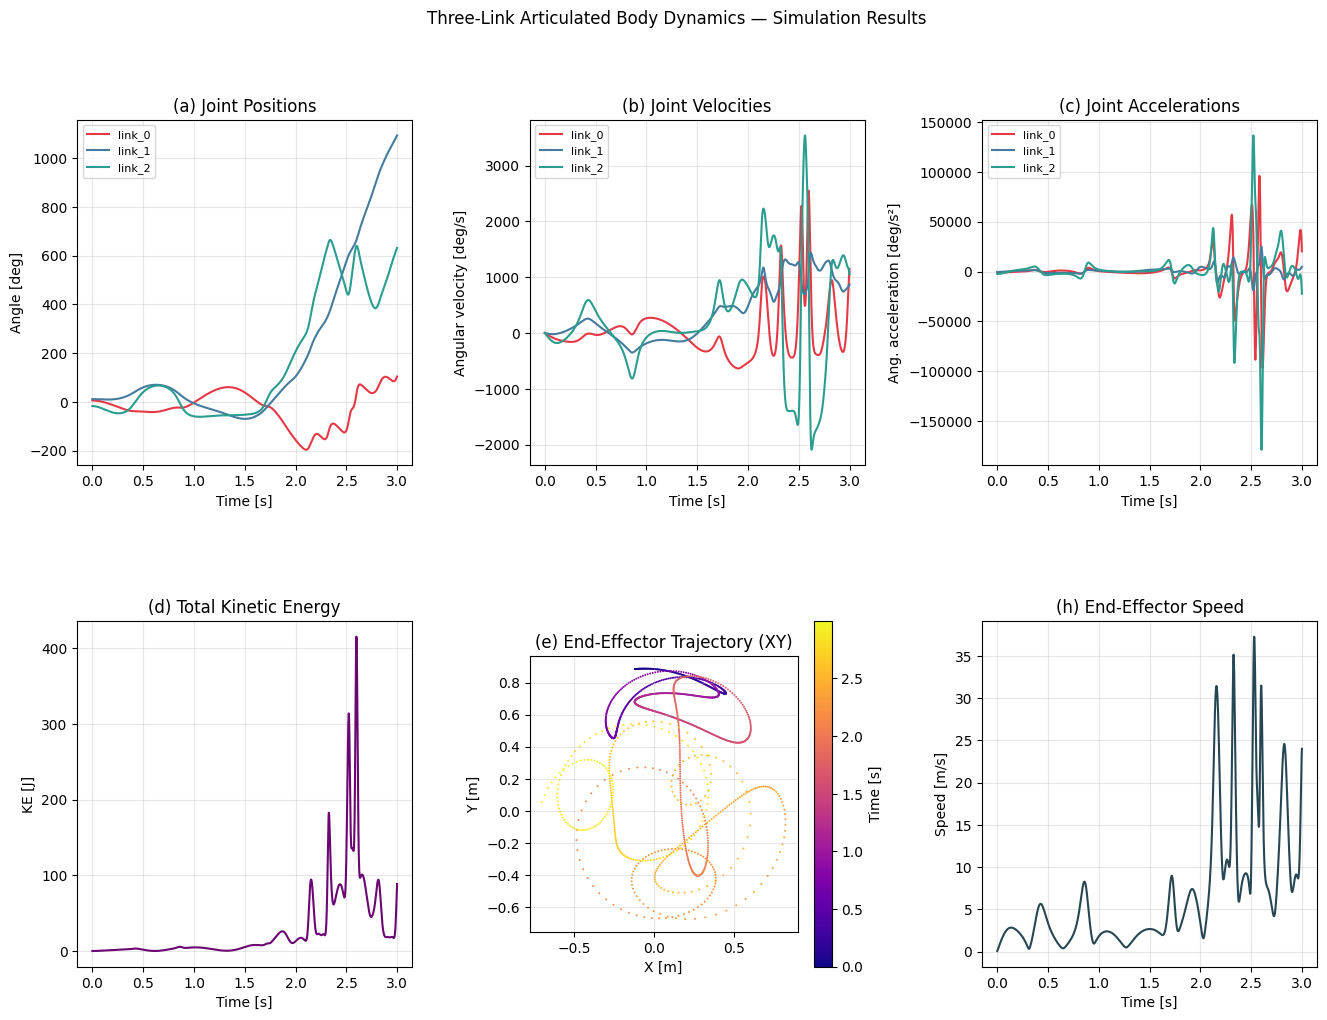

In [243]:
sys = build_threelinks()

# check RNEA at a static pose with gravity 
q0 = np.array([0.0, 0.0, 0.0])
qd0 = np.zeros(3)
tau0 = np.zeros(3)
qdd0 = forward_dynamics_aba(sys, q0, qd0, tau0)
print(f"Joint accelerations at rest under gravity: {qdd0}")

# check RNEA at a nontrivial pose with gravity
q1 = np.array([0.1, 0.2, -0.3])
qd1 = np.array([0.2, -0.1, -0.3])
tau1 = np.array([-0.1, 0.2, -0.3])
qdd1 = forward_dynamics_aba(sys, q1, qd1, tau1)
print(f"Joint accelerations at q={q1}, dq={qd1}, tau={tau1}: {qdd1}")

# consistency check RNEA = original tau
tau_check = inverse_dynamics_rnea(sys, q1, qd1, qdd1)
print(f"RNEA check: tau={tau_check}, original tau={tau1}")
print(f"Max |tau error|: {np.max(np.abs(tau_check - tau1)):.2e}")

# simulate + plot results
q_init = np.array([0.1, 0.2, -0.3])
qd_init = np.array([0.0, 0.0, 0.0])

def zero_torque_fn(q, dq): return np.zeros(3)

results = simulate(sys, q_init, qd_init, zero_torque_fn, dt=0.002, T_final=3.0)
plot_results(results, sys)

In [ ]:
# compare with mujoco
compare_with_mujoco("/Users/sarene/Downloads/SIRL/course_note/docs/contents/3_ArticulatedDynamics/threelinks.xml", sys, q1, qd1, tau1)


=== MuJoCo vs ABA comparison ===
MuJoCo qacc : [ -19.327824   71.606906 -102.924501]
ABA qacc : [-25.274535  -7.955925 -57.162036]
Max |error| : 7.96e+01


(array([ -19.327824,   71.606906, -102.924501]),
 array([-25.274535,  -7.955925, -57.162036]))